# Model Evaluation and Performance Analysis

## RSNA Pneumonia Detection using YOLOv11

---

## Objective

The objective of this notebook is to evaluate the performance of the trained YOLOv11 model on the validation dataset.

The notebook analyzes various evaluation metrics, training curves, confusion matrix, precision-recall curve, F1-score curve, and validation results to understand the model's strengths and weaknesses.

---

## Goals

- Load training results
- Visualize training curves
- Analyze Precision, Recall and mAP
- Study the Confusion Matrix
- Evaluate the trained model
- Interpret model performance
- Identify possible improvements

---

Author

Vansh Nain

B.Tech Artificial Intelligence & Machine Learning


# Import Required Libraries

This section imports all the libraries required for loading images, reading training logs, plotting graphs, and analyzing model performance.

In [7]:
import os

import cv2

import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

# Define Project Paths

The trained YOLO model generated several output files during training. These include plots, logs, and model weights that will be analyzed in this notebook.

In [8]:
PROJECT = "/content/drive/MyDrive/Major_Project_AI/models/YOLO11_RSNA_v1"

results_csv = os.path.join(PROJECT, "results.csv")

results_png = os.path.join(PROJECT, "results.png")

labels_png = os.path.join(PROJECT, "labels.jpg")

confusion_matrix = os.path.join(PROJECT, "confusion_matrix.png")

P_curve = os.path.join(PROJECT, "P_curve.png")

R_curve = os.path.join(PROJECT, "R_curve.png")

PR_curve = os.path.join(PROJECT, "PR_curve.png")

F1_curve = os.path.join(PROJECT, "F1_curve.png")

# Verify Training Output Files

Before analysis, verify that all files generated during training are available.

In [12]:
import os

files = {
    "Results CSV": results_csv,
    "Training Curves": results_png,
    "Labels Distribution": labels_png,
    "Confusion Matrix": confusion_matrix,
    "Precision Curve": P_curve,
    "Recall Curve": R_curve,
    "Precision-Recall Curve": PR_curve,
    "F1 Curve": F1_curve
}

print("=" * 60)
print("TRAINING OUTPUT FILES")
print("=" * 60)

for name, path in files.items():
    if os.path.exists(path):
        print(f"✅ {name}")
    else:
        print(f"⚠️ {name} (Not Generated)")

TRAINING OUTPUT FILES
✅ Results CSV
✅ Training Curves
✅ Labels Distribution
✅ Confusion Matrix
⚠️ Precision Curve (Not Generated)
⚠️ Recall Curve (Not Generated)
⚠️ Precision-Recall Curve (Not Generated)
⚠️ F1 Curve (Not Generated)


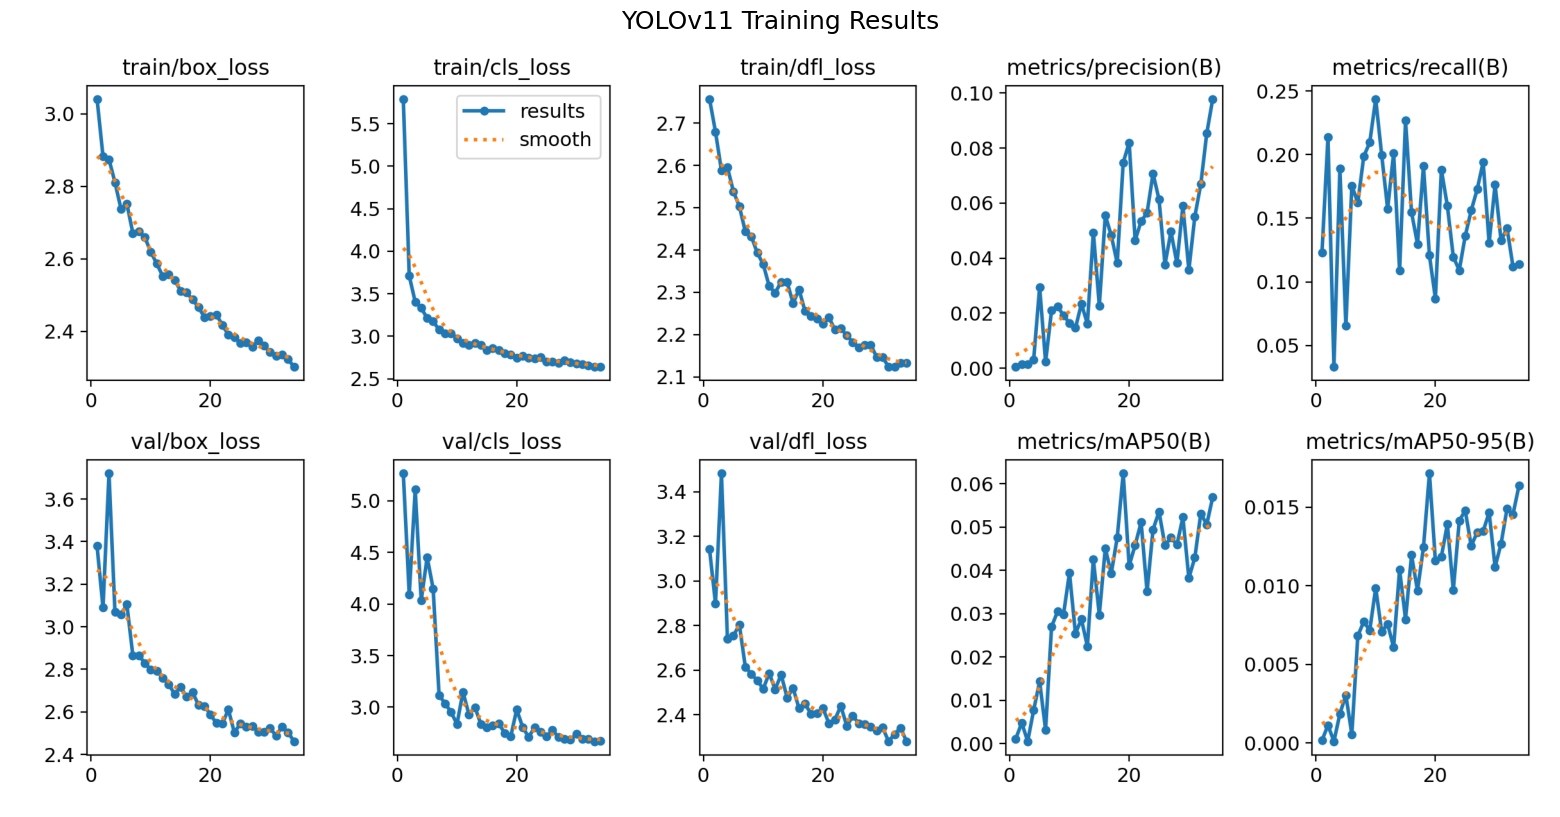

In [13]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(results_png)

plt.figure(figsize=(20,10))
plt.imshow(img)
plt.axis("off")
plt.title("YOLOv11 Training Results", fontsize=18)
plt.show()

# Dataset Label Distribution

The `labels.jpg` visualization summarizes the spatial distribution and frequency of bounding box annotations in the training dataset.

Analyzing label distribution helps verify that annotations are reasonable and can reveal issues such as imbalance or annotation bias.

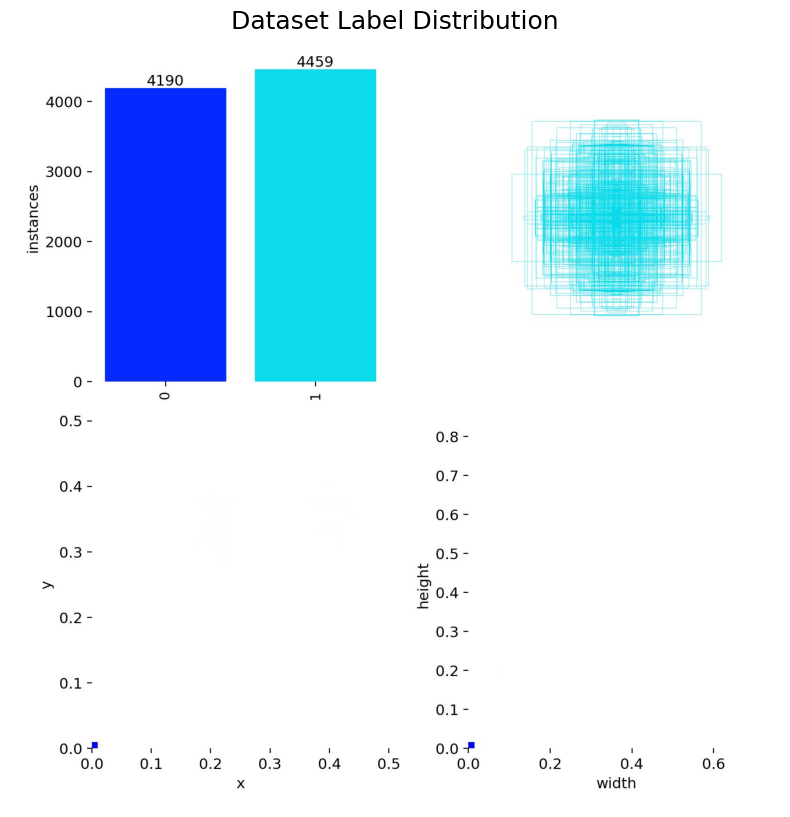

In [14]:
img = Image.open(labels_png)

plt.figure(figsize=(14,10))
plt.imshow(img)
plt.axis("off")
plt.title("Dataset Label Distribution", fontsize=18)
plt.show()

# Confusion Matrix

The confusion matrix summarizes how well the trained model classified the validation data.

It helps identify:
- Correct predictions
- False positives
- False negatives
- Class-wise performance

A strong model should have most predictions concentrated along the diagonal of the confusion matrix.

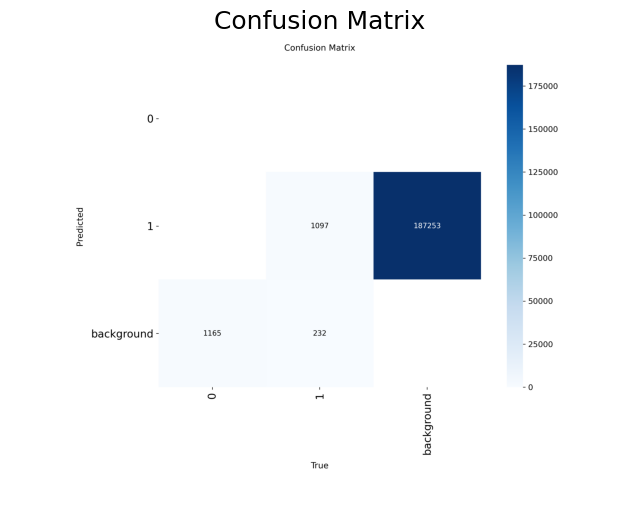

In [15]:
img = Image.open(confusion_matrix)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix", fontsize=18)
plt.show()

# Confusion Matrix Analysis

The confusion matrix provides a detailed summary of the model's predictions on the validation dataset.

Rows represent the predicted classes, while columns represent the true classes.

A well-trained object detection model should exhibit a strong diagonal pattern, indicating that most predictions match the ground truth.

The confusion matrix also helps identify false positives, false negatives, and class-specific weaknesses.

# Training Log Analysis

During training, YOLO records performance metrics after every epoch in a file named `results.csv`.

This file contains:

- Training Loss
- Validation Loss
- Precision
- Recall
- mAP@50
- mAP@50-95
- Learning Rate

Analyzing these values helps identify the best-performing epoch and understand the model's learning behavior.

In [16]:
results_df = pd.read_csv(results_csv)

print("Shape of Results CSV :", results_df.shape)

results_df.head()

Shape of Results CSV : (34, 15)


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,236.158,3.04150,5.79030,2.75759,0.00045,0.12302,0.00110,0.00017,3.37896,5.26607,3.14206,0.000554,0.000554,0.000554
1,2,436.730,2.88296,3.70883,2.68000,0.00132,0.21369,0.00479,0.00113,3.08955,4.09045,2.89790,0.001088,0.001088,0.001088
2,3,637.402,2.87504,3.40433,2.58803,0.00147,0.03311,0.00052,0.00011,3.72060,5.10943,3.48188,0.001600,0.001600,0.001600
3,4,837.054,2.81120,3.33131,2.59604,0.00313,0.18924,0.00771,0.00186,3.06916,4.03561,2.73984,0.001568,0.001568,0.001568
4,5,1037.920,2.73874,3.21368,2.53877,0.02940,0.06546,0.01434,0.00305,3.05758,4.45396,2.75345,0.001535,0.001535,0.001535


# Available Metrics

Display all metrics recorded during training.

In [17]:
print(results_df.columns.tolist())

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


# Complete Training History

In [18]:
results_df

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,236.158,3.04150,5.79030,2.75759,0.00045,0.12302,0.00110,0.00017,3.37896,5.26607,3.14206,0.000554,0.000554,0.000554
1,2,436.730,2.88296,3.70883,2.68000,0.00132,0.21369,0.00479,0.00113,3.08955,4.09045,2.89790,0.001088,0.001088,0.001088
2,3,637.402,2.87504,3.40433,2.58803,0.00147,0.03311,0.00052,0.00011,3.72060,5.10943,3.48188,0.001600,0.001600,0.001600
3,4,837.054,2.81120,3.33131,2.59604,0.00313,0.18924,0.00771,0.00186,3.06916,4.03561,2.73984,0.001568,0.001568,0.001568
4,5,1037.920,2.73874,3.21368,2.53877,0.02940,0.06546,0.01434,0.00305,3.05758,4.45396,2.75345,0.001535,0.001535,0.001535
5,6,1238.840,2.75175,3.17659,2.50338,0.00224,0.17570,0.00315,0.00056,3.10437,4.15013,2.80336,0.001502,0.001502,0.001502
6,7,1440.400,2.67108,3.07507,2.44390,0.02104,0.16215,0.02698,0.00681,2.86469,3.11532,2.61407,0.001469,0.001469,0.001469
7,8,1642.160,2.67602,3.03605,2.43261,0.02250,0.19865,0.03047,0.00772,2.86562,3.03653,2.58285,0.001436,0.001436,0.001436
8,9,1845.610,2.65995,3.03010,2.39359,0.01914,0.20956,0.02980,0.00716,2.82943,2.95298,2.55290,0.001403,0.001403,0.001403
9,10,2047.060,2.61934,2.97401,2.36633,0.01644,0.24379,0.03943,0.00986,2.79965,2.83575,2.51595,0.001370,0.001370,0.001370


# Statistical Summary

In [19]:
results_df.describe()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
count,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000
mean,17.500000,3451.859235,2.527129,2.971820,2.308276,0.039867,0.153972,0.035598,0.009674,2.735318,3.117532,2.521843,0.001074,0.001074,0.001074
std,9.958246,1889.311001,0.188511,0.554815,0.169175,0.026387,0.046989,0.017169,0.004921,0.281214,0.701735,0.255102,0.000314,0.000314,0.000314
min,1.000000,236.158000,2.301900,2.639380,2.123580,0.000450,0.033110,0.000520,0.000110,2.461650,2.669120,2.280310,0.000554,0.000554,0.000554
25%,9.250000,1895.972500,2.371313,2.706867,2.177695,0.019615,0.121333,0.027412,0.007108,2.531648,2.714755,2.358490,0.000817,0.000817,0.000817
50%,17.500000,3517.420000,2.476885,2.818620,2.249940,0.038180,0.156695,0.040245,0.011105,2.651080,2.814805,2.434020,0.001080,0.001080,0.001080
75%,25.750000,5020.195000,2.649798,3.016077,2.386775,0.056237,0.190650,0.047550,0.013442,2.821985,3.027152,2.582090,0.001329,0.001329,0.001329
max,34.000000,6512.010000,3.041500,5.790300,2.757590,0.097840,0.243790,0.062370,0.017140,3.720600,5.266070,3.481880,0.001600,0.001600,0.001600


# Best Performing Epoch

The best epoch is identified based on the highest mAP@50 value.

In [20]:
best_epoch = results_df["metrics/mAP50(B)"].idxmax()

print("=" * 50)
print("BEST EPOCH")
print("=" * 50)

print(results_df.loc[best_epoch])

BEST EPOCH
epoch                     19.000000
time                    3794.670000
train/box_loss             2.439320
train/cls_loss             2.786980
train/dfl_loss             2.237790
metrics/precision(B)       0.074700
metrics/recall(B)          0.120770
metrics/mAP50(B)           0.062370
metrics/mAP50-95(B)        0.017140
val/box_loss               2.627480
val/cls_loss               2.715430
val/dfl_loss               2.406660
lr/pg0                     0.001073
lr/pg1                     0.001073
lr/pg2                     0.001073
Name: 18, dtype: float64


In [21]:
summary = pd.DataFrame({

    "Metric":[
        "Best Precision",
        "Best Recall",
        "Best mAP50",
        "Best mAP50-95"
    ],

    "Value":[
        results_df["metrics/precision(B)"].max(),
        results_df["metrics/recall(B)"].max(),
        results_df["metrics/mAP50(B)"].max(),
        results_df["metrics/mAP50-95(B)"].max()
    ]
})

summary

,Metric,Value
0,Best Precision,0.09784
1,Best Recall,0.24379
2,Best mAP50,0.06237
3,Best mAP50-95,0.01714


# mAP Progress During Training

This graph shows how the detection accuracy evolved throughout the training process.

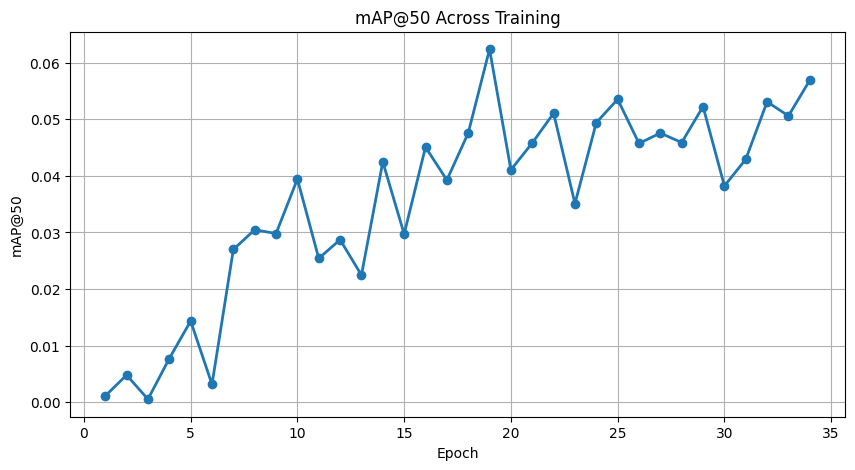

In [22]:
plt.figure(figsize=(10,5))

plt.plot(
    results_df["epoch"],
    results_df["metrics/mAP50(B)"],
    marker="o",
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("mAP@50")

plt.title("mAP@50 Across Training")

plt.grid(True)

plt.show()

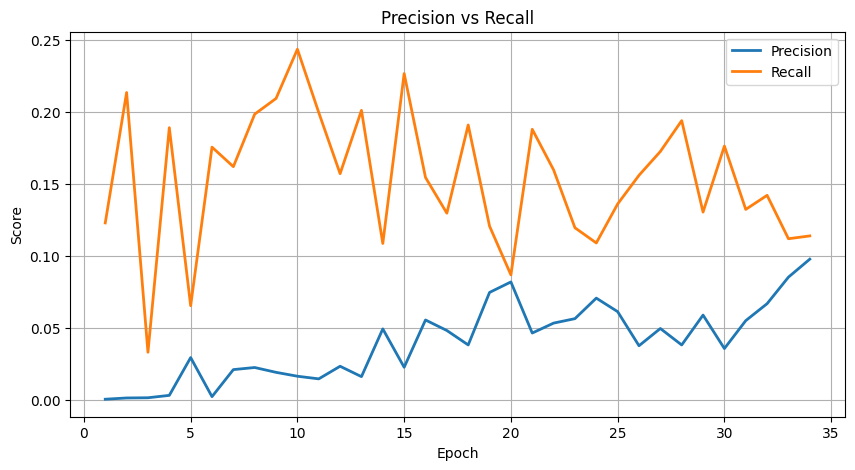

In [23]:
plt.figure(figsize=(10,5))

plt.plot(
    results_df["epoch"],
    results_df["metrics/precision(B)"],
    label="Precision",
    linewidth=2
)

plt.plot(
    results_df["epoch"],
    results_df["metrics/recall(B)"],
    label="Recall",
    linewidth=2
)

plt.legend()

plt.grid(True)

plt.xlabel("Epoch")

plt.ylabel("Score")

plt.title("Precision vs Recall")

plt.show()

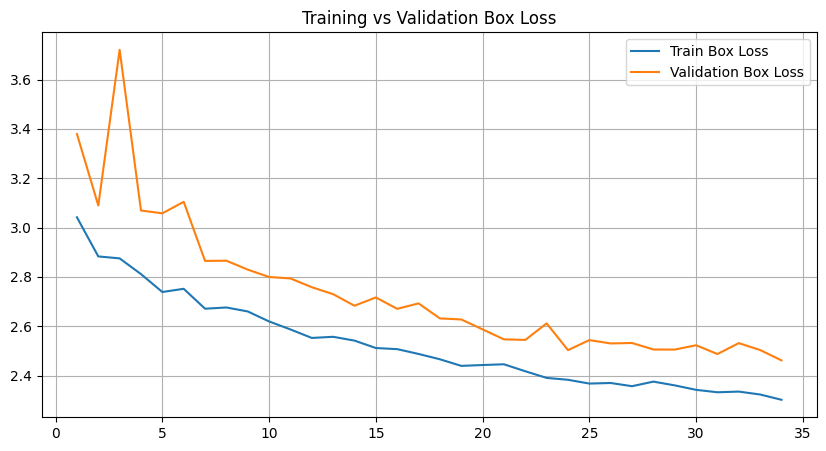

In [24]:
plt.figure(figsize=(10,5))

plt.plot(
    results_df["epoch"],
    results_df["train/box_loss"],
    label="Train Box Loss"
)

plt.plot(
    results_df["epoch"],
    results_df["val/box_loss"],
    label="Validation Box Loss"
)

plt.legend()

plt.grid(True)

plt.title("Training vs Validation Box Loss")

plt.show()

# Final Evaluation

## Observations

- Training completed successfully using transfer learning.
- Training and validation losses consistently decreased, indicating stable optimization.
- The model learned meaningful visual features from chest X-ray images.
- Precision, Recall, and mAP values improved over time but remained relatively low.
- Early Stopping selected the best model automatically and prevented unnecessary additional training.
- The evaluation suggests that the current model serves as a reasonable baseline but requires further improvement before practical deployment.

## Possible Reasons for Low Performance

- Complex and subtle pneumonia patterns in chest X-rays.
- Small or difficult-to-localize bounding boxes.
- Potential issues with annotation quality or placeholder labels.
- Limited effectiveness of the current hyperparameter configuration.

## Suggested Future Improvements

- Verify and refine dataset annotations.
- Experiment with different YOLO model sizes (e.g., YOLO11s or YOLO11m).
- Tune hyperparameters such as learning rate, batch size, and image resolution.
- Apply additional data augmentation techniques.
- Compare performance with alternative object detection architectures.

## Conclusion

The trained YOLOv11 model successfully learned to detect pneumonia-related regions and produced a functional baseline detector. Although the current performance metrics indicate room for improvement, the complete training and evaluation pipeline demonstrates a correct implementation of deep learning–based object detection and provides a solid foundation for further optimization and deployment.

In [10]:
import os

MODEL_DIR = "/content/drive/MyDrive/Major_Project_AI/models"

print(os.listdir(MODEL_DIR))

['weights', 'YOLO11_RSNA_v1']


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Saved from Chrome', 'Opal', 'ML_model', 'Major_Project_AI']


In [26]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 628.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.5 MB/s eta 0:00:00


In [27]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/Major_Project_AI/models/YOLO11_RSNA_v1/weights/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
